# Лабораторна робота № 1
## Багатокритеріальний вибір. Визначення оптимальних альтернатив за Парето та Слейтером

**Варіант 19.** Обидва критерії максимізуються.

### Мета роботи
Ознайомитись з поняттями оптимальності за Парето та за Слейтером при багатокритеріальному виборі.


### Короткі теоретичні відомості

Багатокритеріальний вибір задають множина альтернатив $X$, вектор критеріїв $f=(Q_1,Q_2)$ та відношення переваги. Тут бажані більші значення обох критеріїв.

- **Домінування за Парето:** $x$ не гірше за $y$ за кожним критерієм і краще хоча б за одним. Парето-оптимальну альтернативу не домінує жодна інша.
- **Домінування за Слейтером:** $x$ строго краще за $y$ за кожним критерієм. Альтернативу, оптимальну за Слейтером, ніхто так не домінує.
- Кожна Парето-оптимальна альтернатива оптимальна за Слейтером: $P(X) \subseteq S(X)$. Альтернативи з однаковими координатами залишаються окремими і не домінують одна одну.

Для кожної альтернативи шукається інша, що її домінує. Перший знайдений домінатор заноситься до аналітичної таблиці.


### Варіант та вихідні дані

У кожному двоцифровому коді перша цифра є $Q_1$, друга — $Q_2$: `93` → $(9,3)$, `09` → $(0,9)$, `04` → $(0,4)$. Нижче наведено три рядки варіанта 19.


In [1]:
VARIANT = 19
rows = [
    ["52", "21", "93", "90", "89", "09", "31", "73", "64", "35", "48", "95", "77", "13", "33", "98", "49", "55", "55", "93"],
    ["68", "56", "60", "33", "23", "86", "71", "58", "77", "40", "45", "81", "61", "90", "23", "50", "51", "54", "75", "64"],
    ["42", "24", "59", "19", "89", "44", "69", "38", "51", "76", "83", "19", "33", "43", "04", "56", "81", "75", "66", "11"],
]
assert all(len(row) == 20 for row in rows), "Кожен рядок має містити 20 значень"
print(f"Варіант {VARIANT}")
for number, row in enumerate(rows, 1):
    print(f"Рядок {number}: {' '.join(row)}")


Варіант 19
Рядок 1: 52 21 93 90 89 09 31 73 64 35 48 95 77 13 33 98 49 55 55 93
Рядок 2: 68 56 60 33 23 86 71 58 77 40 45 81 61 90 23 50 51 54 75 64
Рядок 3: 42 24 59 19 89 44 69 38 51 76 83 19 33 43 04 56 81 75 66 11


### Реалізація

Пошук оптимальних альтернатив виконується попарним порівнянням.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def parse_alternatives(values: list[int | str], start_index: int = 1) -> pd.DataFrame:
    points = []
    for value in values:
        code = str(value).zfill(2)
        if len(code) != 2 or not code.isdecimal():
            raise ValueError(f"Некоректний двоцифровий код: {value!r}")
        points.append((int(code[0]), int(code[1])))
    labels = [f"A{i}" for i in range(start_index, start_index + len(points))]
    return pd.DataFrame(points, index=pd.Index(labels, name="Альтернатива"), columns=["Q1", "Q2"])


def pareto_dominates(a, b, criteria) -> bool:
    return all(a[c] >= b[c] for c in criteria) and any(a[c] > b[c] for c in criteria)


def slater_dominates(a, b, criteria) -> bool:
    return all(a[c] > b[c] for c in criteria)


def find_dominators(df: pd.DataFrame, criteria, dominates) -> dict[str, str | None]:
    result = {}
    for name, point in df.iterrows():
        result[name] = next(
            (other_name for other_name, other in df.iterrows()
             if other_name != name and dominates(other, point, criteria)),
            None,
        )
    return result


def find_pareto_optimal(df: pd.DataFrame, criteria=("Q1", "Q2")) -> list[str]:
    dominators = find_dominators(df, criteria, pareto_dominates)
    return [name for name, dominator in dominators.items() if dominator is None]


def find_slater_optimal(df: pd.DataFrame, criteria=("Q1", "Q2")) -> list[str]:
    dominators = find_dominators(df, criteria, slater_dominates)
    return [name for name, dominator in dominators.items() if dominator is None]


def build_analysis_table(df: pd.DataFrame, criteria=("Q1", "Q2")) -> pd.DataFrame:
    result = df.copy()
    result["Домінується за Парето"] = pd.Series(find_dominators(df, criteria, pareto_dominates)).fillna("—")
    result["Домінується за Слейтером"] = pd.Series(find_dominators(df, criteria, slater_dominates)).fillna("—")
    return result


def format_set(df: pd.DataFrame, names: list[str]) -> str:
    groups = {}
    for name in names:
        point = tuple(df.loc[name, ["Q1", "Q2"]])
        groups.setdefault(point, []).append(name)
    return ", ".join("=".join(labels) for labels in groups.values())


def plot_frontier(df, optimal_alternatives, method_name, title, criteria=("Q1", "Q2")):
    x_name, y_name = criteria
    optimal = set(optimal_alternatives)
    groups = {}
    for name, point in df.iterrows():
        groups.setdefault((point[x_name], point[y_name]), []).append(name)

    fig, ax = plt.subplots(figsize=(12, 8))
    for (x, y), labels in groups.items():
        is_optimal = labels[0] in optimal
        ax.scatter(x, y, s=75 if is_optimal else 35,
                   color="#d95f02" if is_optimal else "#606b77",
                   zorder=3 if is_optimal else 2)
        label = "=".join(labels)
        ax.annotate(label, (x, y), xytext=(-5 if x >= 8 else 5, -11 if y >= 8 else 6),
                    textcoords="offset points", fontsize=8,
                    ha="right" if x >= 8 else "left",
                    color="#8c3900" if is_optimal else "#303840",
                    bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=0.3))

    frontier = sorted({(df.loc[name, x_name], df.loc[name, y_name]) for name in optimal},
                      key=lambda point: (point[0], -point[1]))
    if len(frontier) > 1:
        ax.plot([x for x, _ in frontier], [y for _, y in frontier],
                color="#d95f02", linewidth=1.5, zorder=1)
    ax.set(xlabel=x_name, ylabel=y_name, title=title, xlim=(-0.5, 10), ylim=(-0.5, 10))
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return fig


### Перевірка реалізації

Контрольний приклад: `{79, 95, 4, 37, 92, 95, 12, 52, 70, 14}`. Очікувані множини: Парето — `A1, A2=A6`; Слейтера — `A1, A2=A6, A5`.


In [3]:
assert pareto_dominates({"Q1": 9, "Q2": 9}, {"Q1": 9, "Q2": 5}, ("Q1", "Q2"))
assert slater_dominates({"Q1": 9, "Q2": 9}, {"Q1": 8, "Q2": 5}, ("Q1", "Q2"))
assert not slater_dominates({"Q1": 9, "Q2": 9}, {"Q1": 9, "Q2": 5}, ("Q1", "Q2"))
assert not pareto_dominates({"Q1": 9, "Q2": 9}, {"Q1": 9, "Q2": 9}, ("Q1", "Q2"))
assert not slater_dominates({"Q1": 9, "Q2": 9}, {"Q1": 9, "Q2": 9}, ("Q1", "Q2"))
assert parse_alternatives([4, "04"]).to_numpy().tolist() == [[0, 4], [0, 4]]
example = parse_alternatives([79, 95, 4, 37, 92, 95, 12, 52, 70, 14])
assert find_pareto_optimal(example) == ["A1", "A2", "A6"]
assert find_slater_optimal(example) == ["A1", "A2", "A5", "A6"]
print("Контрольний приклад і граничні випадки: пройдено")


Контрольний приклад і граничні випадки: пройдено


In [4]:
datasets = {f"Рядок {i}": parse_alternatives(row) for i, row in enumerate(rows, 1)}
datasets["A1–A60"] = parse_alternatives([value for row in rows for value in row])
assert [len(df) for df in datasets.values()] == [20, 20, 20, 60]
assert datasets["A1–A60"].index.tolist() == [f"A{i}" for i in range(1, 61)]


def show_dataset(name: str, df: pd.DataFrame):
    pareto_set = find_pareto_optimal(df)
    slater_set = find_slater_optimal(df)
    assert set(pareto_set) <= set(slater_set), f"P(X) не є підмножиною S(X): {name}"
    print(f"{name}: таблиця значень критеріїв (аналог табл. 1.1)")
    display(df)
    print(f"{name}: таблиця домінування (аналог табл. 1.2)")
    display(build_analysis_table(df))
    print("Множина Парето:", format_set(df, pareto_set))
    print("Множина Слейтера:", format_set(df, slater_set))
    plot_frontier(df, pareto_set, "Парето", f"Границя Парето — {name}")
    plot_frontier(df, slater_set, "Слейтера", f"Границя Слейтера — {name}")
    return {"Набір": name, "Альтернатив": len(df), "Парето, кількість": len(pareto_set),
            "Множина Парето": format_set(df, pareto_set), "Слейтер, кількість": len(slater_set),
            "Множина Слейтера": format_set(df, slater_set)}


### Рядок 1

Рядок 1: таблиця значень критеріїв (аналог табл. 1.1)


,Q1,Q2
Альтернатива,,
A1,5,2
A2,2,1
A3,9,3
A4,9,0
A5,8,9
A6,0,9
A7,3,1
A8,7,3
A9,6,4


Рядок 1: таблиця домінування (аналог табл. 1.2)


,Q1,Q2,Домінується за Парето,Домінується за Слейтером
Альтернатива,,,,
A1,5,2,A3,A3
A2,2,1,A1,A1
A3,9,3,A12,—
A4,9,0,A3,—
A5,8,9,—,—
A6,0,9,A5,—
A7,3,1,A1,A1
A8,7,3,A3,A5
A9,6,4,A5,A5


Множина Парето: A5, A16
Множина Слейтера: A3=A20, A4, A5, A6, A12, A16, A17


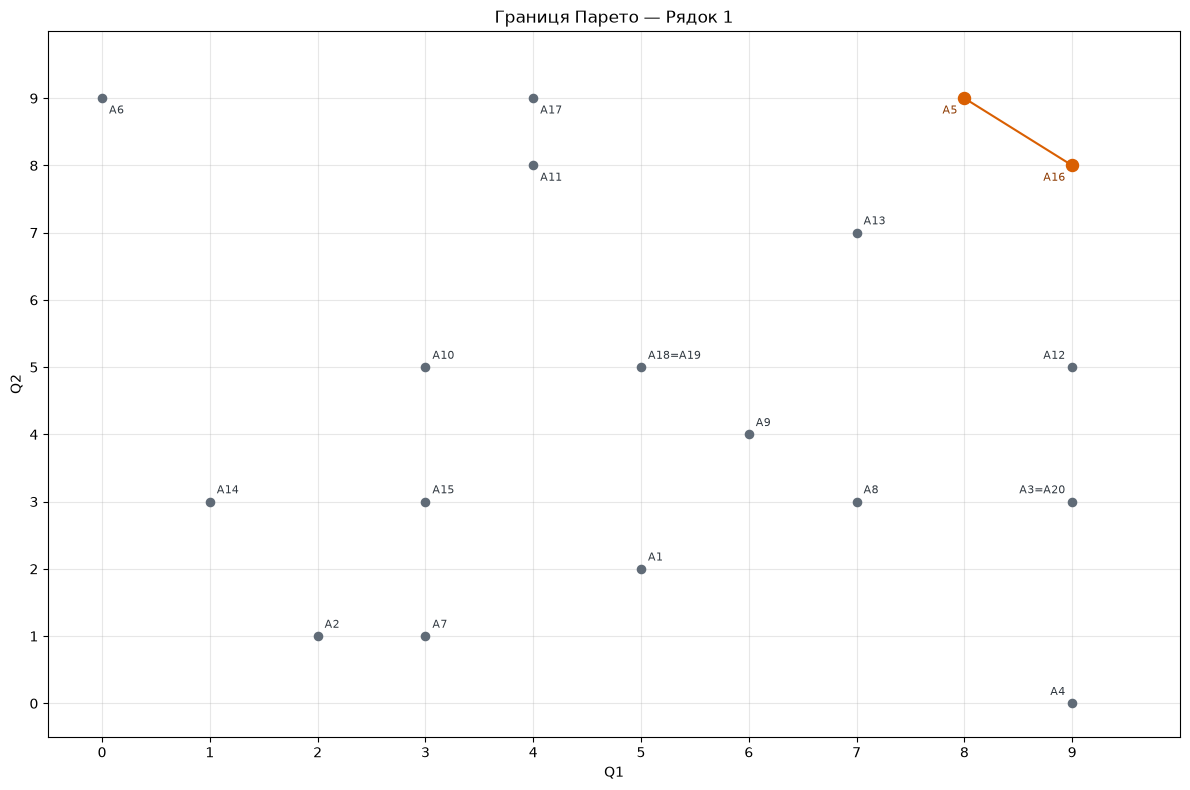

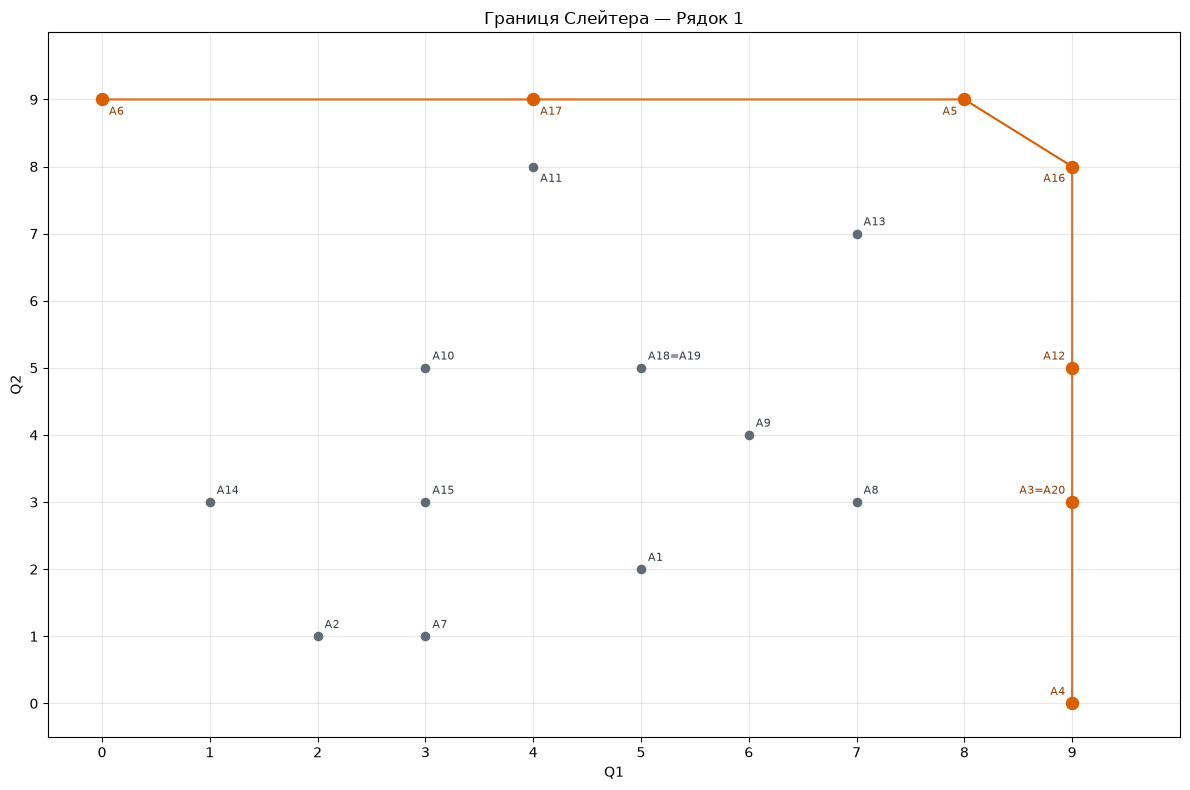

In [5]:
result_4 = show_dataset('Рядок 1', datasets['Рядок 1'])

### Рядок 2

Рядок 2: таблиця значень критеріїв (аналог табл. 1.1)


,Q1,Q2
Альтернатива,,
A1,6,8
A2,5,6
A3,6,0
A4,3,3
A5,2,3
A6,8,6
A7,7,1
A8,5,8
A9,7,7


Рядок 2: таблиця домінування (аналог табл. 1.2)


,Q1,Q2,Домінується за Парето,Домінується за Слейтером
Альтернатива,,,,
A1,6,8,—,—
A2,5,6,A1,A1
A3,6,0,A1,A6
A4,3,3,A1,A1
A5,2,3,A1,A1
A6,8,6,—,—
A7,7,1,A6,A6
A8,5,8,A1,—
A9,7,7,—,—


Множина Парето: A1, A6, A9, A14
Множина Слейтера: A1, A6, A8, A9, A12, A14


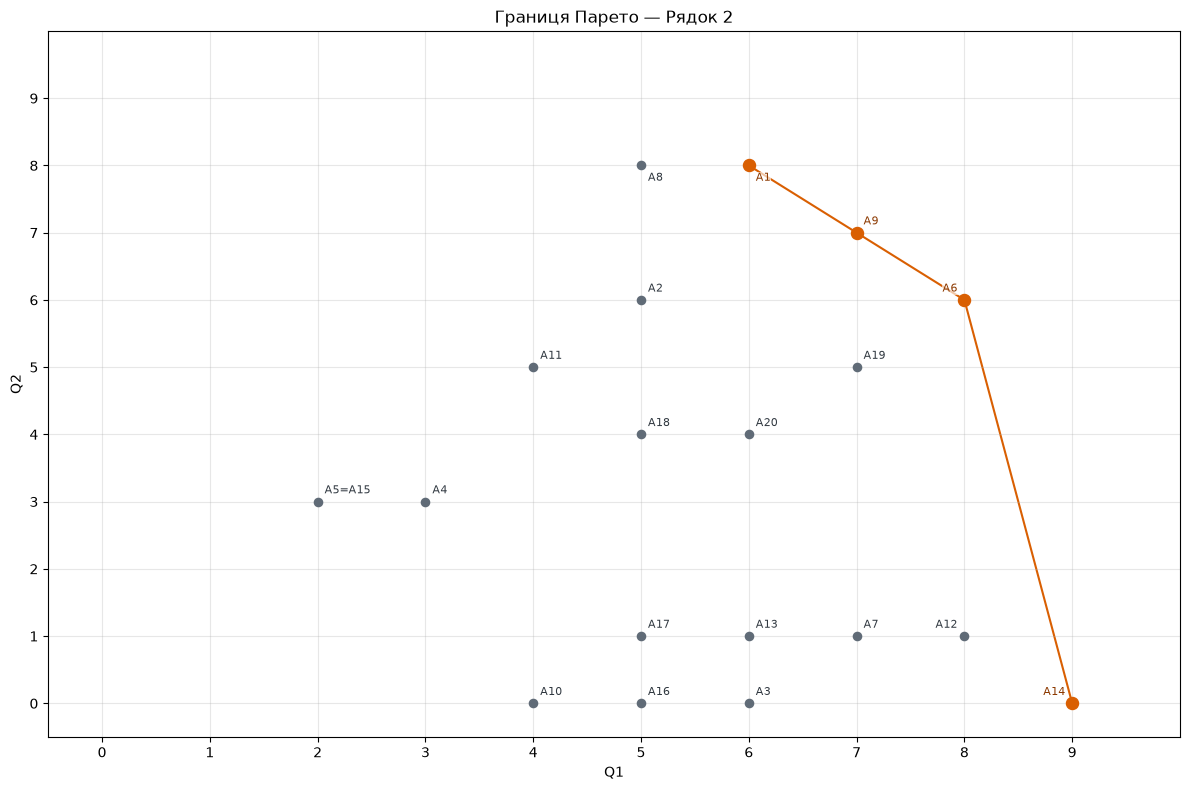

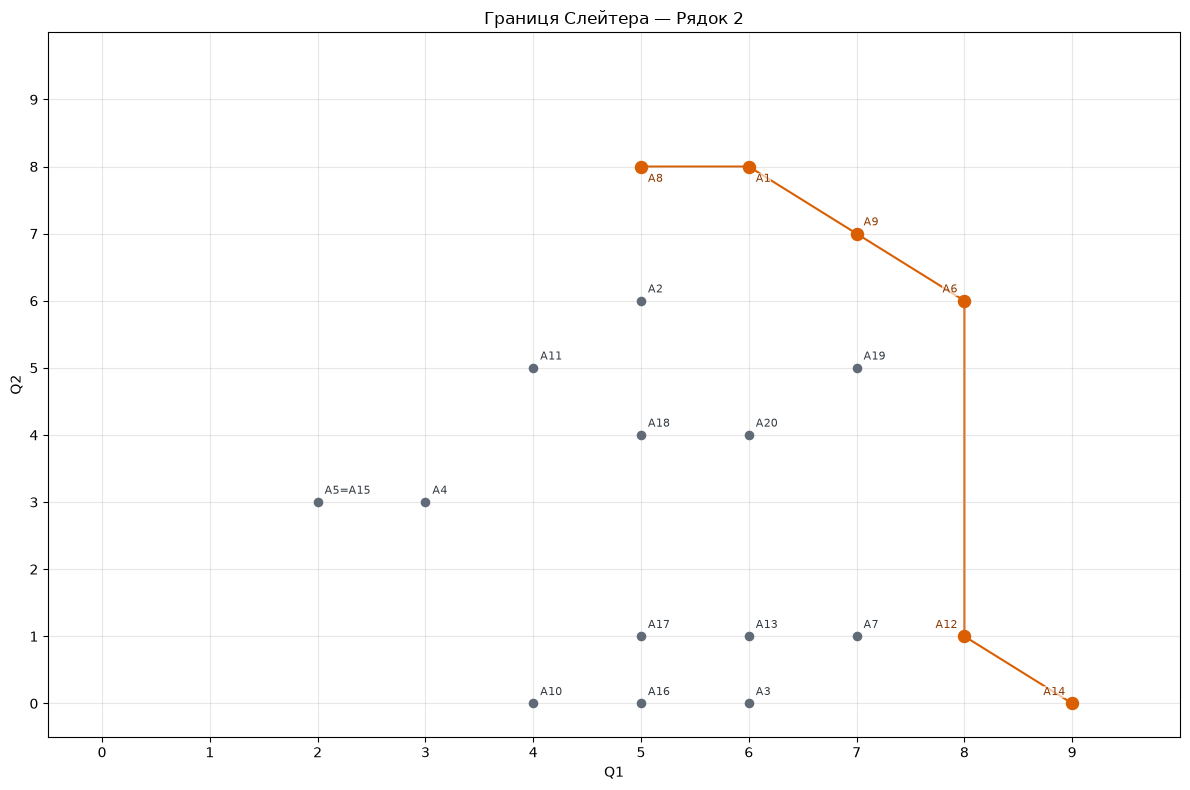

In [6]:
result_5 = show_dataset('Рядок 2', datasets['Рядок 2'])

### Рядок 3

Рядок 3: таблиця значень критеріїв (аналог табл. 1.1)


,Q1,Q2
Альтернатива,,
A1,4,2
A2,2,4
A3,5,9
A4,1,9
A5,8,9
A6,4,4
A7,6,9
A8,3,8
A9,5,1


Рядок 3: таблиця домінування (аналог табл. 1.2)


,Q1,Q2,Домінується за Парето,Домінується за Слейтером
Альтернатива,,,,
A1,4,2,A3,A3
A2,2,4,A3,A3
A3,5,9,A5,—
A4,1,9,A3,—
A5,8,9,—,—
A6,4,4,A3,A3
A7,6,9,A5,—
A8,3,8,A3,A3
A9,5,1,A3,A5


Множина Парето: A5
Множина Слейтера: A3, A4=A12, A5, A7, A11, A17


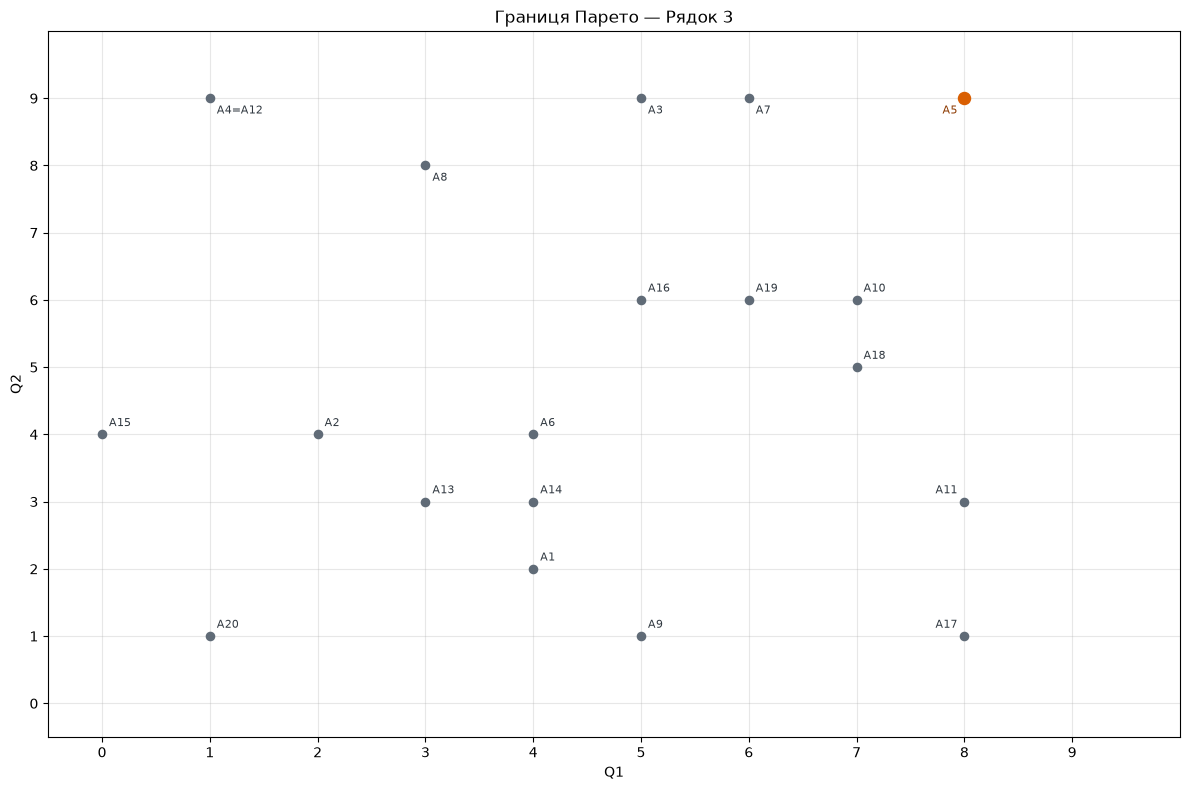

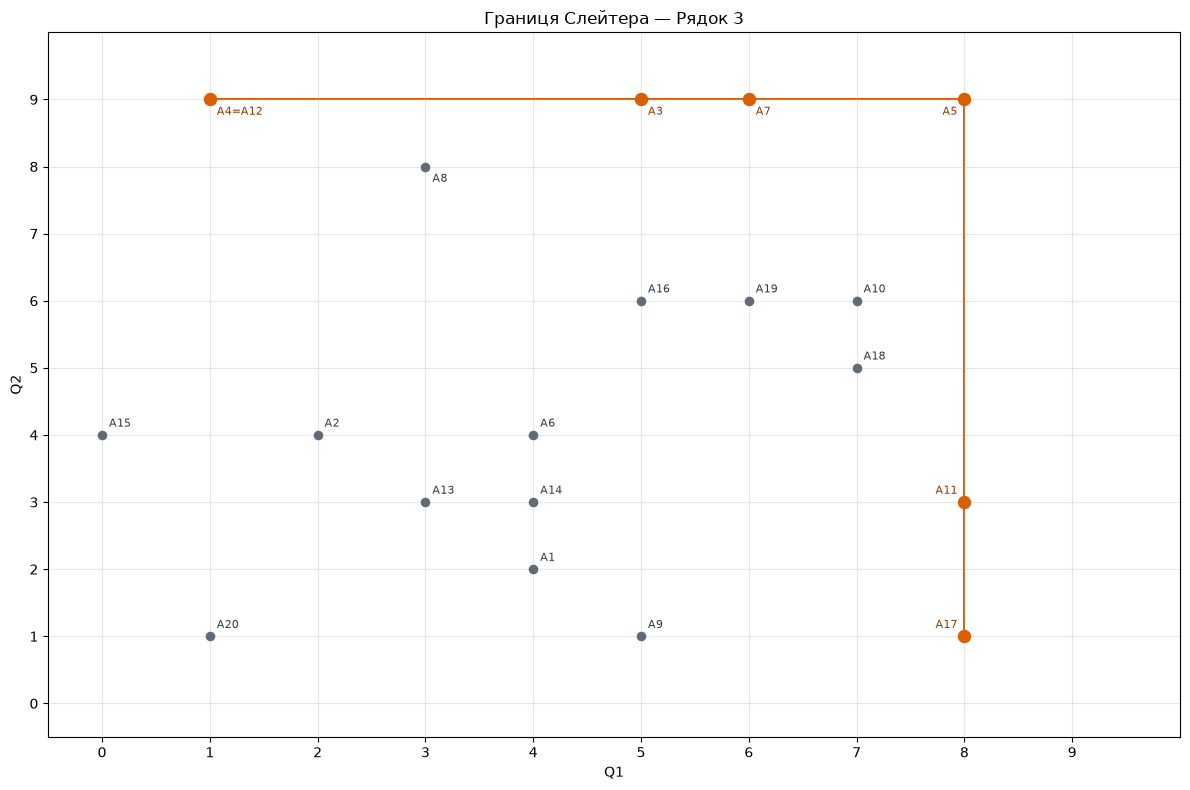

In [7]:
result_6 = show_dataset('Рядок 3', datasets['Рядок 3'])

### A1–A60

Порядок у спільній множині: перший рядок — `A1–A20`, другий — `A21–A40`, третій — `A41–A60`. Збіги координат не вилучаються.

A1–A60: таблиця значень критеріїв (аналог табл. 1.1)


,Q1,Q2
Альтернатива,,
A1,5,2
A2,2,1
A3,9,3
A4,9,0
A5,8,9
A6,0,9
A7,3,1
A8,7,3
A9,6,4


A1–A60: таблиця домінування (аналог табл. 1.2)


,Q1,Q2,Домінується за Парето,Домінується за Слейтером
Альтернатива,,,,
A1,5,2,A3,A3
A2,2,1,A1,A1
A3,9,3,A12,—
A4,9,0,A3,—
A5,8,9,—,—
A6,0,9,A5,—
A7,3,1,A1,A1
A8,7,3,A3,A5
A9,6,4,A5,A5


Множина Парето: A5=A45, A16
Множина Слейтера: A3=A20, A4=A34, A5=A45, A6, A12, A16, A17, A43, A44=A52, A47


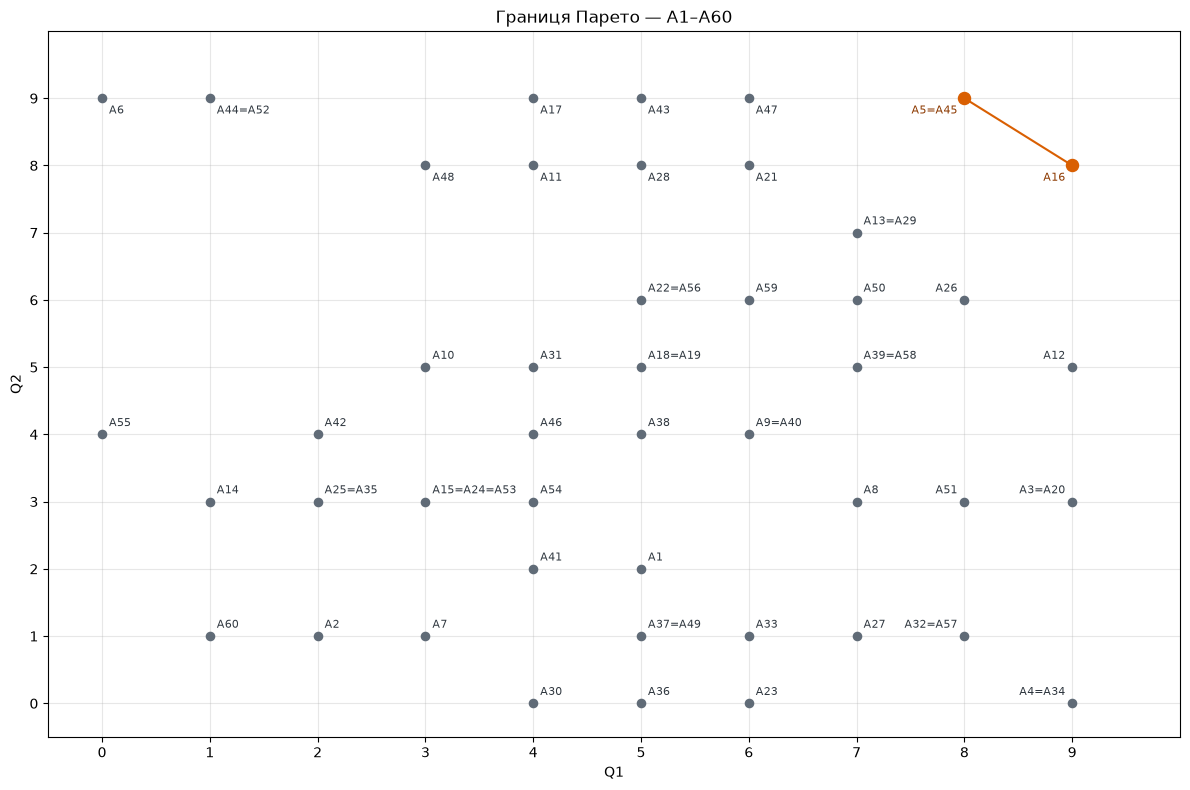

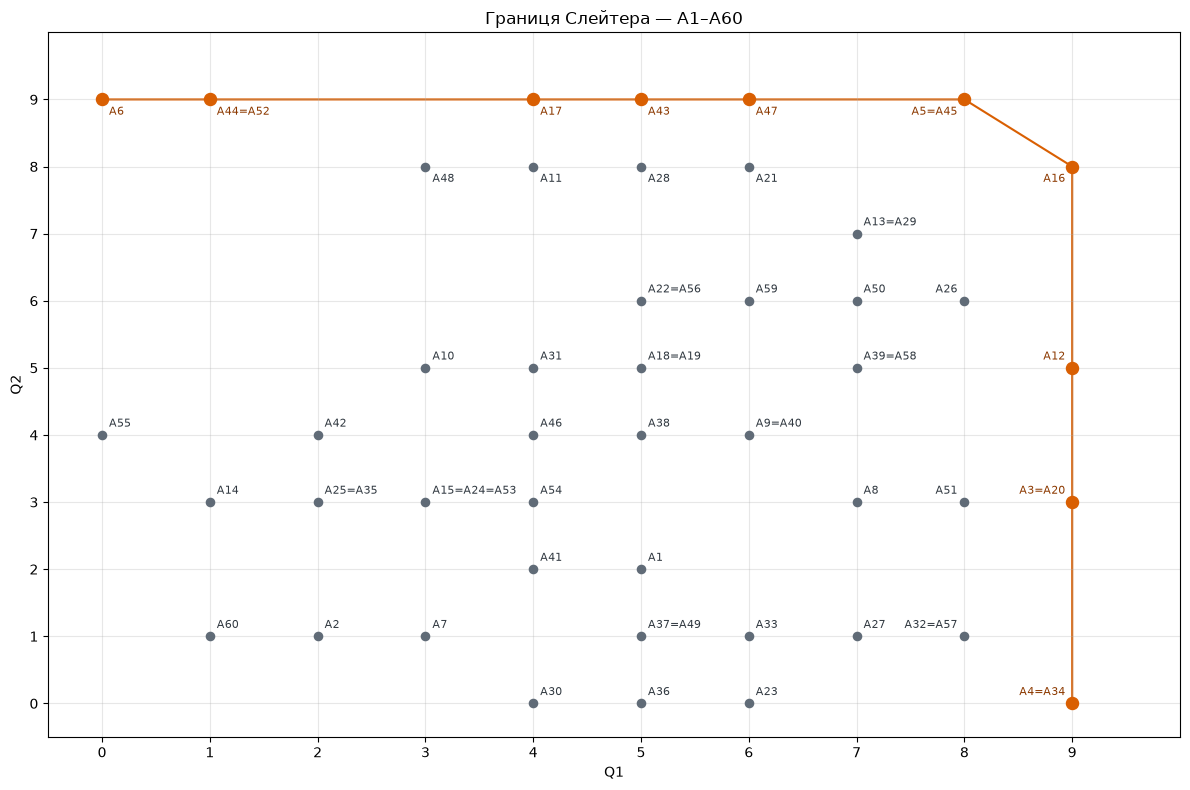

In [8]:
result_7 = show_dataset('A1–A60', datasets['A1–A60'])

### Підсумкові результати та висновки

Кількості й назви нижче обчислюються з даних варіанта під час запуску. Перевірка $P(X) \subseteq S(X)$ виконується окремо для кожного набору.


In [9]:
summary = pd.DataFrame([
    {"Набір": name, "Альтернатив": len(df),
     "Парето, кількість": len(find_pareto_optimal(df)),
     "Множина Парето": format_set(df, find_pareto_optimal(df)),
     "Слейтер, кількість": len(find_slater_optimal(df)),
     "Множина Слейтера": format_set(df, find_slater_optimal(df))}
    for name, df in datasets.items()
])
display(summary)
for row in summary.itertuples(index=False):
    print(f"{row[0]}: проаналізовано {row[1]} альтернатив; "
          f"оптимальних за Парето — {row[2]}, за Слейтером — {row[4]}.")
print("Для всіх чотирьох наборів P(X) ⊆ S(X).")


,Набір,Альтернатив,"Парето, кількість",Множина Парето,"Слейтер, кількість",Множина Слейтера
0,Рядок 1,20,2,"A5, A16",8,"A3=A20, A4, A5, A6, A12, A16, A17"
1,Рядок 2,20,4,"A1, A6, A9, A14",6,"A1, A6, A8, A9, A12, A14"
2,Рядок 3,20,1,A5,7,"A3, A4=A12, A5, A7, A11, A17"
3,A1–A60,60,3,"A5=A45, A16",14,"A3=A20, A4=A34, A5=A45, A6, A12, A16, A17, A43..."


Рядок 1: проаналізовано 20 альтернатив; оптимальних за Парето — 2, за Слейтером — 8.
Рядок 2: проаналізовано 20 альтернатив; оптимальних за Парето — 4, за Слейтером — 6.
Рядок 3: проаналізовано 20 альтернатив; оптимальних за Парето — 1, за Слейтером — 7.
A1–A60: проаналізовано 60 альтернатив; оптимальних за Парето — 3, за Слейтером — 14.
Для всіх чотирьох наборів P(X) ⊆ S(X).


### Висновок

У ході лабораторної роботи реалізовано попарне порівняння альтернатив за двома критеріями, що максимізуються, побудовано таблиці домінування та графіки оптимальних множин. Коректність реалізації перевірено на контрольному прикладі та граничних випадках, зокрема для альтернатив з однаковими координатами.

Для варіанта 19 у першому рядку отримано 2 альтернативи, оптимальні за Парето, та 8 — за Слейтером; у другому — 4 та 6; у третьому — 1 та 7 відповідно. Для спільної множини з 60 альтернатив множина Парето складається з **A5, A16 та A45**, а множина Слейтера містить **14 альтернатив**. Альтернативи A5 та A45 мають однакові значення критеріїв $(8,9)$, а A16 — $(9,8)$; жодна з цих двох точок не домінує іншу.

Для всіх досліджених наборів підтверджено співвідношення $P(X) \subseteq S(X)$. Множина Слейтера є ширшою, оскільки її домінування вимагає строгого покращення обох критеріїв, тоді як для домінування за Парето достатньо покращення хоча б одного без погіршення іншого. Наприклад, у спільній множині A12 з координатами $(9,5)$ оптимальна за Слейтером, але домінується за Парето альтернативою A16 з координатами $(9,8)$.

Отже, критерій Парето звужує вибір до альтернатив, які неможливо покращити за одним критерієм без погіршення іншого. Щоб обрати між $(8,9)$ та $(9,8)$, необхідно додатково визначити пріоритети критеріїв або вподобання особи, яка приймає рішення.
